In [2]:
from autoenkoop import *
import torch
from torch.utils.data import DataLoader
import numpy as np
import pandas as pd
import os
import pydmd
from tqdm import tqdm
from matplotlib.colors import Normalize

DEVICE = "cuda"

In [3]:
data_path = os.path.join("..", "data", "T1492_x1151_y1_z127_c2.npz")
center_dataset = True
train_test_split = 0.7
train_data, test_data, temp_mean = load_and_prepare_data(data_path, center_dataset, train_test_split)

In [4]:
full_data = np.concatenate((train_data, test_data), axis=0)

original_data = full_data + temp_mean
temp_mean_error = np.mean((full_data - temp_mean)**2, axis=(1,2,3))
(vx_min, vx_max), (vz_min, vz_max) = get_min_max(original_data)
vx_absmax = max(abs(vx_min), abs(vx_max))*0.2
vz_absmax = max(abs(vz_min), abs(vz_max))*0.2
norm_x = Normalize(vmin=-vx_absmax, vmax=+vx_absmax)
norm_z = Normalize(vmin=-vz_absmax, vmax=+vz_absmax)

prediction_window = 100
window_offset_data = full_data[:-prediction_window]

dataset_full = SimpleDataset(window_offset_data)

loader_full = DataLoader(dataset_full, batch_size=1, shuffle=False, num_workers=2, pin_memory=True, persistent_workers=True)

dataset_train = SimpleDataset(train_data)
loader_train = DataLoader(dataset_train, batch_size=4, shuffle=False)

full_data = np.moveaxis(full_data, -1, 1)

In [5]:
train_test_cutoff = int(full_data.shape[0]*0.7)
print(train_test_cutoff)

1045


In [6]:
#example_index = 0
#
#vx = original_data[example_index, :, :, 0]
#vz = original_data[example_index, :, :, 1]
#
#plot_vx_vz(vx, vz, norm_x, norm_z)
#animate_trajectory(np.moveaxis(original_data[0:50], -1, 1), "original", norm_x, norm_z)

In [7]:
def calculate_koopman(model, loader):
    Z = []
    with torch.no_grad():
        for x_t in loader:
            x_t = x_t.to(DEVICE)
            #encoded current state
            z_t = model.encoder(x_t) 
            Z.append(z_t.cpu().numpy())
    Z_all = np.vstack(Z).T
    dmd = pydmd.DMD(-1, forward_backward=False)
    dmd.fit(Z_all)
    K_star = (dmd.modes @ np.diag(dmd.eigs) @ np.linalg.pinv(dmd.modes)).real
    return K_star

In [8]:
def predict_window(x_t, model, linfunction, window_length):
    with torch.no_grad():
        z_t = model.encoder(x_t)
                
        window_prediction = []
        x_t_predicted = model.decoder(z_t).cpu().numpy()
        window_prediction.append(x_t_predicted)
                
        for i in range(window_length):
            z_t = linfunction(z_t)
            x_t_predicted = model.decoder(z_t).cpu().numpy()
            window_prediction.append(x_t_predicted)
                
    return np.vstack(window_prediction)

L32_e300_lr1e-4_lamlin1_dmd


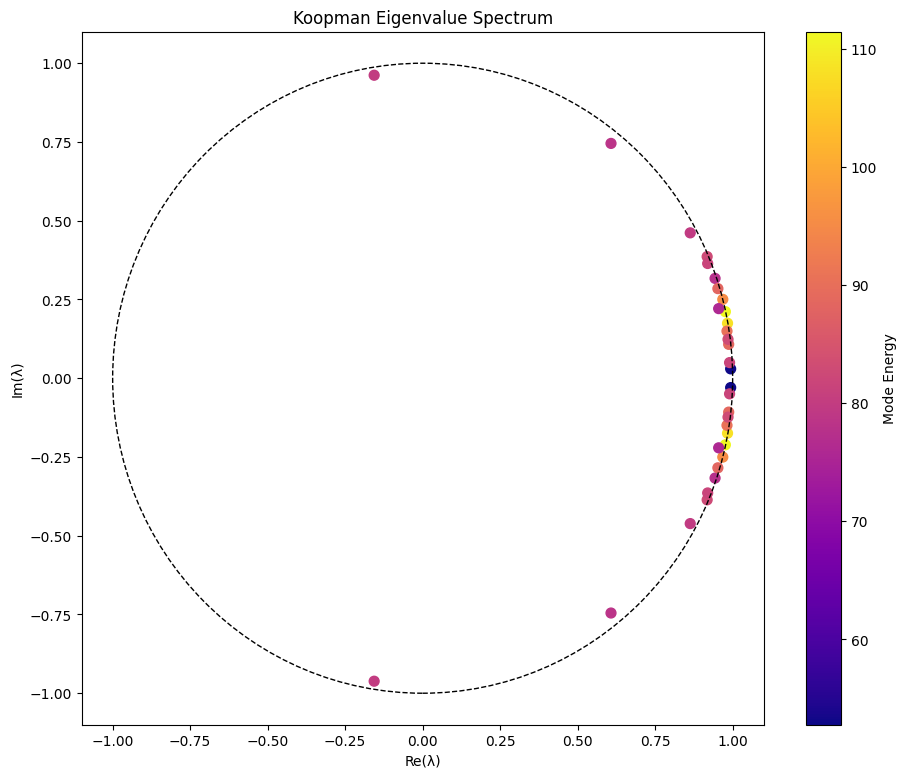

L128_e300_lr2e-4_lamlin1_train


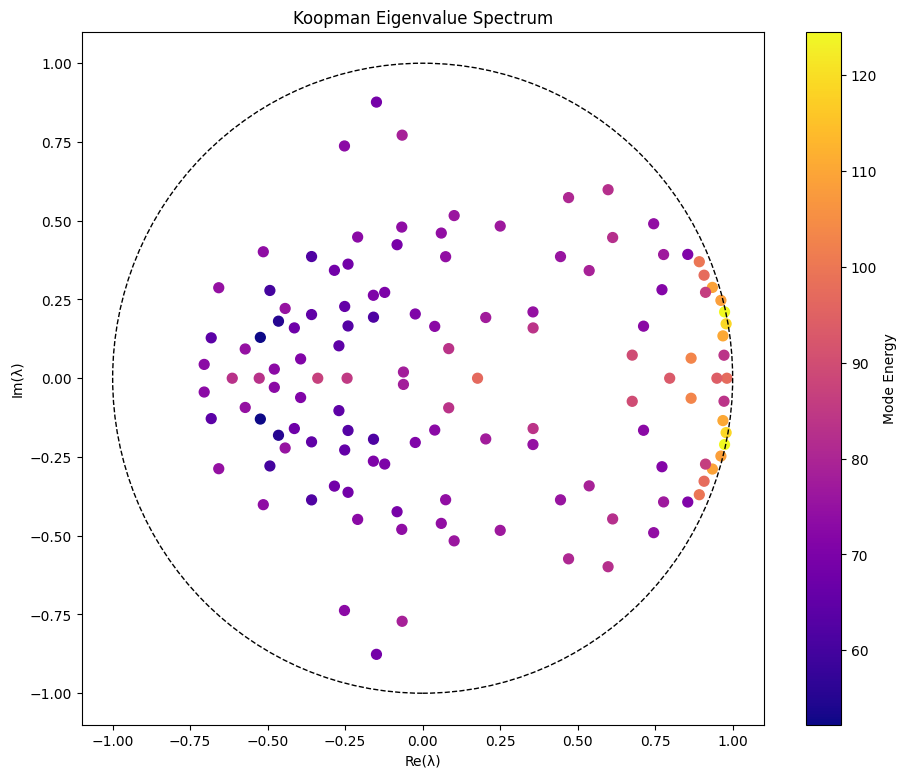

L32_e300_lr1e-4_lamlin1_fb_dmd


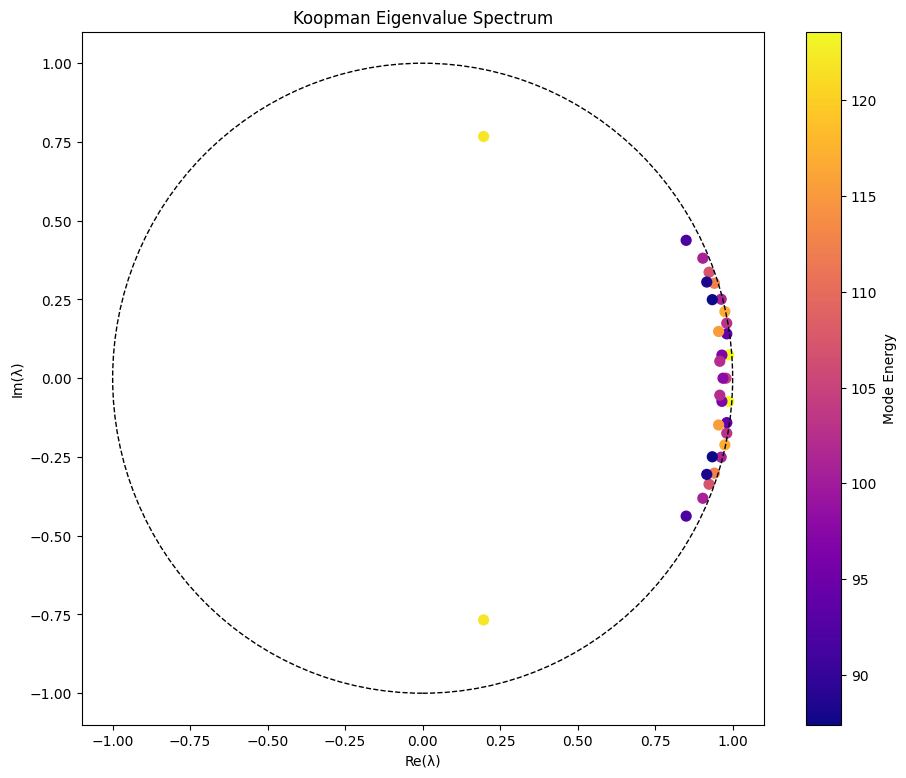

L32_e300_lr1e-4_lamlin10_dmd


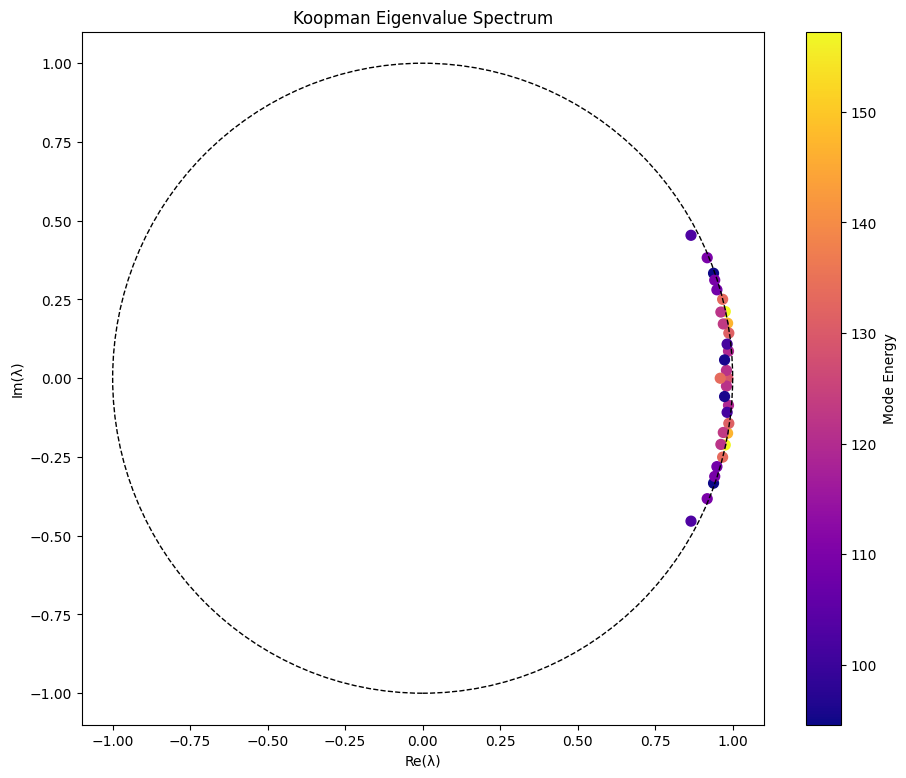

L32_e300_lr1e-4_lamlin10_fb_dmd


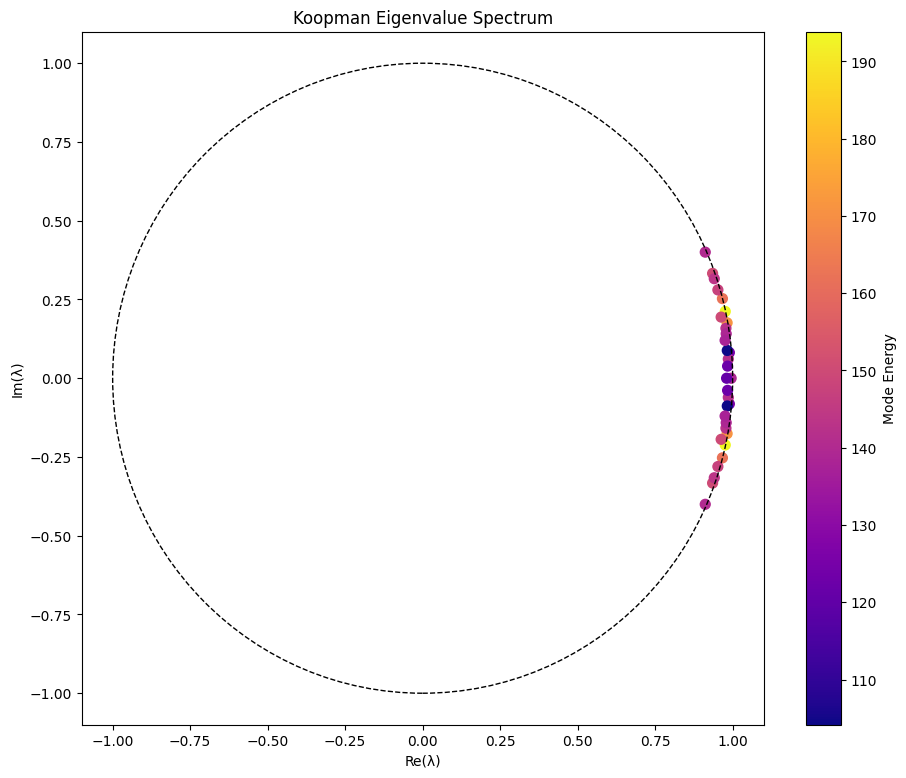

L32_e300_lr4e-4_lamlin100_dmd


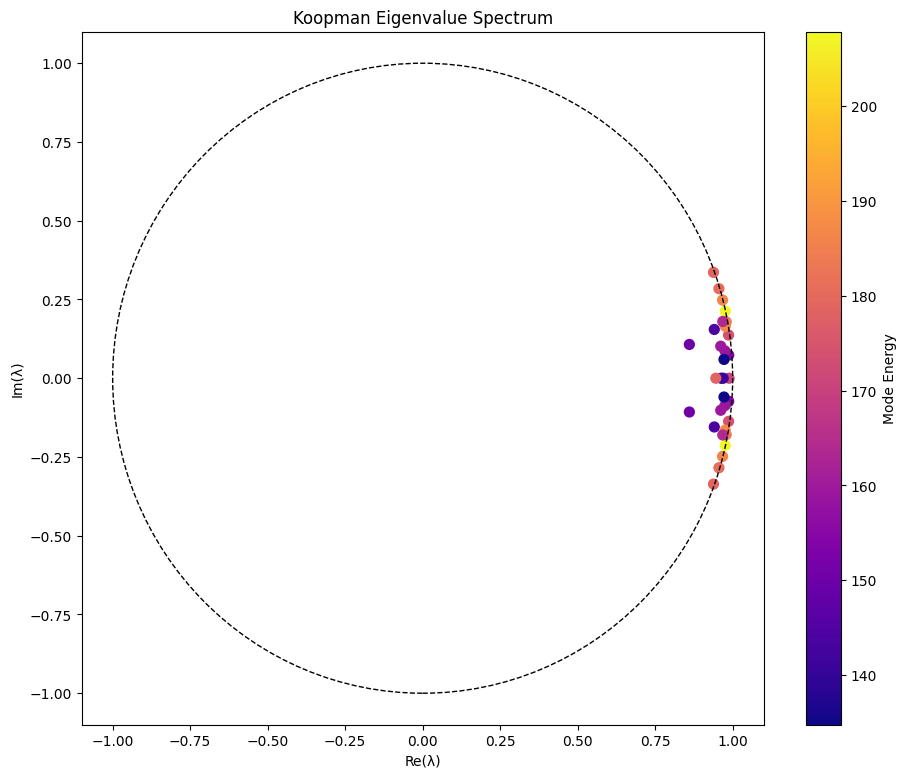

100%|██████████| 1393/1393 [05:32<00:00,  4.19it/s]


In [73]:
results_path = os.path.join("..", "results")
run_name_list = [
    #"L128_e300_lamlin1_train",
    #"L128_e300_lr1e-4_lamlin1_train",
    "L32_e300_lr1e-4_lamlin1_dmd",
    "L128_e300_lr2e-4_lamlin1_train",
    "L32_e300_lr1e-4_lamlin1_fb_dmd",
    "L32_e300_lr1e-4_lamlin10_dmd",
    "L32_e300_lr1e-4_lamlin10_fb_dmd",
    "L32_e300_lr4e-4_lamlin100_dmd"
    #"L32_e300_lamlin1_dmd",
    #"L32_e300_lamlin10_dmd",
    #"L128_e300_lamlin10_dmd",
    #"L32_e300_lr0.0002_K0Dec_equalW_dmd",
    #"L32_e300_lamlin1_lrgroup",
    #"L32_e300_lamlin10_lrgroup",
    #"L32_e300_lr2e-4_lamlin10_dmd",
    #"L32_e300_lr2e-4_lamlin1_dmd",
    #"L128_e300_lr2e-4_lamlin1_dmd"
    ]

prediction_mse_windows = []

for run_name in run_name_list:
    print(run_name)
    run_path = os.path.join(results_path, "kae_experiments", run_name)
    
    hyperparam = run_name.split('_')
    
    LATENT_DIM = int(hyperparam[0][1:])
    koopman_type = hyperparam[-1]
    
    model = ConvAutoencoderZeroDecoder(latent_dim=LATENT_DIM).to(DEVICE)
    
    model.load_state_dict(torch.load(os.path.join(run_path, "model.pt"), map_location=DEVICE))
    model.eval()

    if koopman_type == "dmd":
        K = calculate_koopman(model, loader_train)
        lin_weights = torch.tensor(K, device=DEVICE, requires_grad=True)
        linfunction = lambda z_t : torch.nn.functional.linear(z_t, lin_weights)
    else:
        linfunction = lambda z_t : model.linear_dynamics(z_t)
        with torch.no_grad():
            K = model.linear_dynamics.weight.detach().cpu().numpy()
    
    eigvalues, eigvectors = get_sorted_eigen(K)
    eigenergies = eigenvalue_energies(model, eigvectors, DEVICE)
    plot_eigenvalue_spectrum(eigvalues, eigvectors, eigenergies)
    prediction_window_path = os.path.join(run_path,"pred_window_mse.npy")
    if os.path.exists(prediction_window_path):
        prediction_mse = np.load(prediction_window_path)
    else:
        prediction_mse = np.zeros((window_offset_data.shape[0], prediction_window+1))
        with torch.no_grad():
            for j, x_t in tqdm(enumerate(loader_full), total=len(dataset_full)):
                x_t = x_t.to(DEVICE)
                X_prediction = predict_window(x_t, model, linfunction, prediction_window)
                mse_window = np.mean((full_data[j:j+prediction_window+1] - X_prediction)**2, axis=(1,2,3))
                prediction_mse[j] = mse_window
        np.save(prediction_window_path[:-4], prediction_mse)
    prediction_mse_windows.append(prediction_mse)
    #        
    #
    
    #
    #break

In [ ]:
steady_tolerance = 0.17

stable_values, stable_vectors, stable_energies = get_stable_modes(eigvalues, eigvectors, eigenergies, steady_tolerance, False)

In [ ]:
def prediction_mse(data, start_index, prediction_length, eigenvalues, eigenvectors, model, device="cpu"):
    x0 = torch.tensor(data[start_index]).unsqueeze(0).to(device)
    stable_predicted_trajectory = predict_trajectory_reduced(x0, model, eigenvalues, eigenvectors, prediction_length, device)
    stable_predicted_trajectory = np.array(stable_predicted_trajectory).reshape(prediction_length, -1)
    true_trajectory = np.permute_dims(data[start_index:start_index+prediction_length]).reshape(prediction_length, -1)
    mse = np.mean((stable_predicted_trajectory - true_trajectory)**2, 1)
    return mse

In [62]:
mse_list = []
for i in tqdm(range(len(dataset_full))):
    mse_list.append(prediction_mse(full_data, i, prediction_window, stable_values.to(DEVICE), stable_vectors.to(DEVICE), model, DEVICE))
mse_array32 = np.array(mse_list)

  0%|          | 0/1393 [00:00<?, ?it/s]


NameError: name 'stable_values' is not defined

In [ ]:
np.save(prediction_window_path[:-4]+"32C", mse_array32)

In [ ]:
prediction_mse_windows.append(mse_array32)

In [ ]:
run_name_list.append("L128_e300_lr2e-4_lamlin1_train 32 modes C")

In [ ]:
mode_values, mode_vectors, mode_energies = filter_pos_imag(eigvalues, eigvectors, eigenergies)
stable_structures = calculate_eigenmode_structures(mode_vectors, model, device=DEVICE)
for i, structure in enumerate(stable_structures):
    print(mode_values[i].item(),"\t", np.abs(mode_values[i].item()))
    print(mode_energies[i])
    vx = structure[0,:]
    vz = structure[1,:]
    plot_vx_vz(vx, vz, norm_x, norm_z)

In [ ]:
x_t = dataset_full[1147]
x_t = x_t.to(DEVICE).unsqueeze(0)
X_prediction = predict_window(x_t, model, linfunction, prediction_window)

In [ ]:
X_prediction.shape

In [ ]:
#example_index = 0
#
#vx = original_data[example_index, :, :, 0]
#vz = original_data[example_index, :, :, 1]
#
#plot_vx_vz(vx, vz, norm_x, norm_z)
animate_trajectory(X_prediction+np.moveaxis(temp_mean, -1, 0), "prev_index_mode", norm_x, norm_z)

In [74]:
global_mse_list = []

for i, windowed_mse in enumerate(prediction_mse_windows):
    #if run_name_list[i] != "L128_e300_lamlin10_train":
    global_mse_list.append(np.mean(windowed_mse, 0))

In [75]:
train_mean_mse = []
test_mean_mse = []

for i, windowed_mse in enumerate(prediction_mse_windows):
    #if run_name_list[i] != "L128_e300_lamlin10_train":
    train_mean_mse.append(np.mean(windowed_mse[:train_test_cutoff], 0))
    test_mean_mse.append(np.mean(windowed_mse[train_test_cutoff:], 0))

In [76]:
mean_mse_list = []

for i, windowed_mse in enumerate(prediction_mse_windows):
    #if run_name_list[i] != "L128_e300_lamlin10_train":
    mean_mse_list.append(np.mean(windowed_mse, 1))

In [77]:
#selected_mse_list = [global_mse_list[0]] + global_mse_list[2:-1]
#label_list = [run_name_list[0]] + run_name_list[2:-1]
#run_name_list = ["L128_e300_lamlin1_train", "L32_e300_lamlin1_dmd"]

In [78]:
train_test_name_list = [name+" TRAIN" for name in run_name_list]+[name+" TEST" for name in run_name_list]

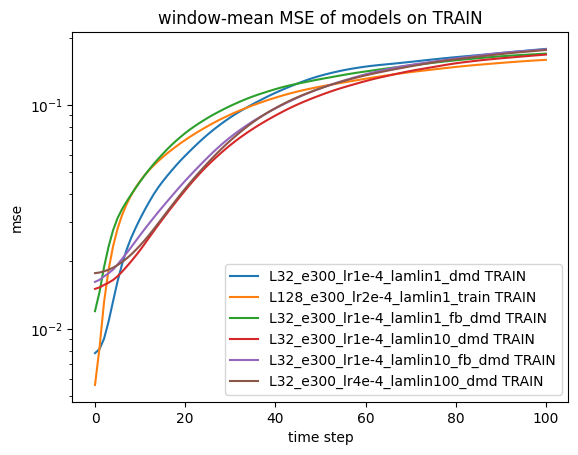

In [79]:
plot_evolution(train_mean_mse, [name+" TRAIN" for name in run_name_list], "window-mean MSE of models on TRAIN", "time step", "mse")

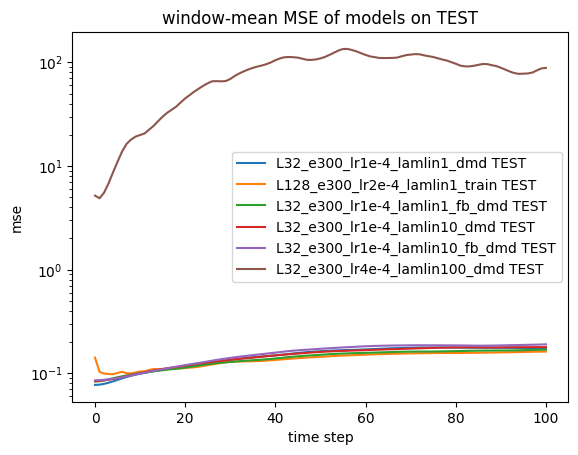

In [80]:
plot_evolution(test_mean_mse, [name+" TEST" for name in run_name_list], "window-mean MSE of models on TEST", "time step", "mse")

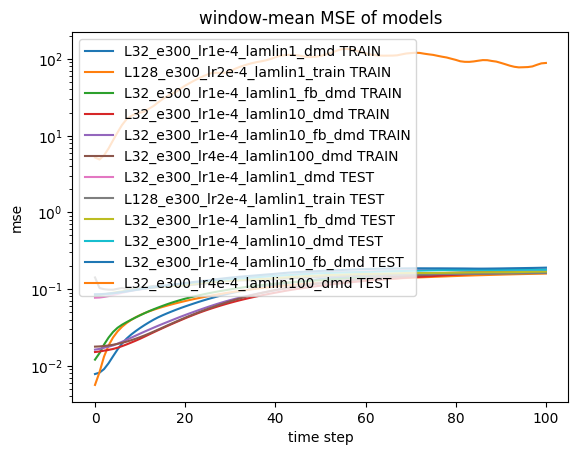

In [81]:
plot_evolution(train_mean_mse + test_mean_mse, train_test_name_list, "window-mean MSE of models", "time step", "mse")

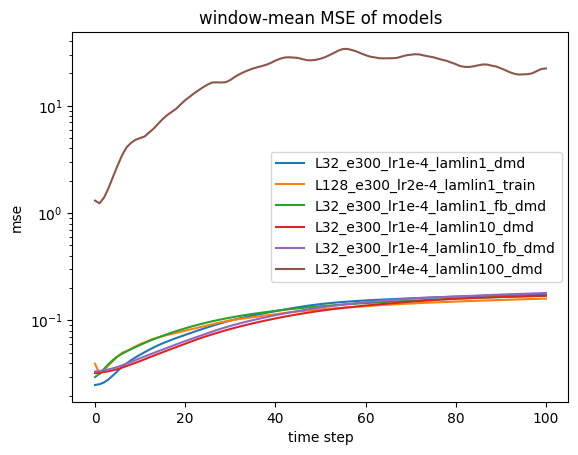

In [82]:
plot_evolution(global_mse_list, run_name_list, "window-mean MSE of models", "time step", "mse")

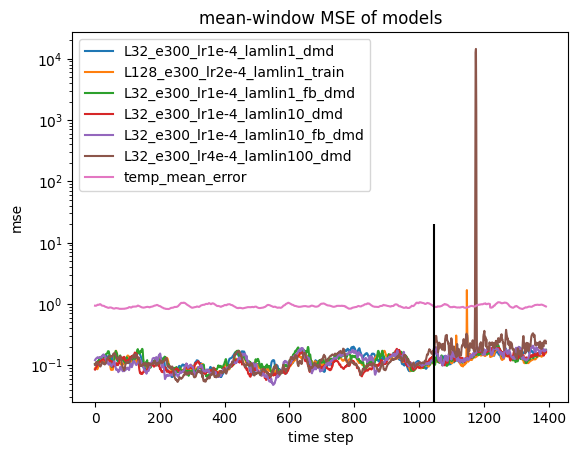

In [83]:
plot_evolution(mean_mse_list+[temp_mean_error[:1393]], run_name_list+["temp_mean_error"], "mean-window MSE of models", "time step", "mse")
plt.vlines(train_test_cutoff, 0, 20, colors=["black"])

In [84]:
mean_mse_list[0][1147]

np.float64(0.12790820017309473)

In [ ]:
#1148

In [ ]:
temp_mean_error